# Kết hợp các phép đo bằng Logistic Regression

[Bài 01](01_eda_and_baseline.ipynb) đặt bốn câu hỏi về tệp ảnh, màu sắc, chi tiết và vùng nhìn. Ở đây ta thử kết hợp các phép đo thay vì quyết định chỉ từ dung lượng. Bài này tự nạp dữ liệu nên có thể chạy từ kernel mới.

Ta sẽ xây một vector cho mỗi ảnh, học cách so sánh hai vector, rồi đối chiếu với luật dung lượng trên cùng các fold. Sau khi có kết quả baseline, ta mới thử từng nhóm riêng và bỏ từng nhóm để tìm hiểu đóng góp của chúng. Chưa có lý do để kết luận trước rằng dùng đủ 32 đặc trưng sẽ tốt nhất.

In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kmd.core import PACKAGE, read_csv, split_fold, metric
from kmd.extractor import (
    NAMES, features, get_lr_features, list_lr_ablations,
    extract_file_size_features, extract_color_stats, extract_hsv_stats,
    extract_gray_stats, extract_gradient_stats, extract_residual_stats,
    extract_blockiness_stats, extract_center_border_stats
)
from kmd.pipeline import prepare_development, start_session, fit_lr_fold, fit_lr_cv, extract_pair_features, aligned_predictions
from kmd.suite import run_lr_suite
from kmd.teaching import resolve_data_roots, show_pair_images

KMD_SMOKE = os.environ.get('KMD_SMOKE', '0') == '1'
KMD_RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
RUN_ID = f"{KMD_RUN_ID}_smoke" if (KMD_SMOKE and not KMD_RUN_ID.endswith('_smoke')) else KMD_RUN_ID

data_root, test_root = resolve_data_roots(TASK_ROOT)
if not data_root.is_dir() or not (data_root / 'pairs.csv').is_file():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục dữ liệu huấn luyện tại '{data_root}'. "
        "Vui lòng thiết lập biến môi trường DATA_ROOT trỏ đến thư mục chứa 'pairs.csv' và 'images/'."
    )

dev_frame = prepare_development(data_root)
session_dir = start_session(dev_frame, data_root, run_id=RUN_ID)
print(f"Thư mục dự án: {TASK_ROOT}")
print(f"Phiên làm việc: {session_dir.relative_to(PACKAGE)}")
print(f"Tổng số mẫu phát triển: {len(dev_frame)}")

Thư mục dự án: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh
Phiên làm việc: artifacts/models/lesson_full_v5_20260920
Tổng số mẫu phát triển: 800


## 1. Cấu trúc 32 đặc trưng và động lực mở rộng từ 4 hướng khảo sát

Một mean không mô tả hết một phân bố. Ta bổ sung std để đo độ phân tán, phân vị để nhìn phần tối/sáng, rồi dùng một số phép đo thay đổi cục bộ khác nhau. Số 32 là tổng số đại lượng của thiết kế này, không phải số chiều tối ưu đã được tìm ra.

Bốn nhóm có lần lượt 1, 18, 9 và 4 đặc trưng:
- Nhóm 1: Dung lượng tệp (1 đặc trưng: `log_bytes`).
- Nhóm 2: Thống kê màu sắc và độ sáng (18 đặc trưng):
  - Trung bình và độ lệch chuẩn của các kênh RGB (6 đặc trưng).
  - Phân vị 10% và 90% của RGB (6 đặc trưng): phân vị mô tả phía thấp (q10) và phía cao (q90) của giá trị kênh mà không bị méo bởi vài điểm ảnh nhiễu cực đoan.
  - Trung bình và độ lệch chuẩn của kênh độ bão hòa (Saturation) và độ sáng (Value) trong không gian HSV (4 đặc trưng).
  - Trung bình và độ lệch chuẩn ảnh xám (2 đặc trưng).
- Nhóm 3: Kết cấu và phần dư (9 đặc trưng):
  - `entropy`: Entropy tính từ histogram độ sáng 64 bins. entropy của histogram đo mức độ phân tán của các mức xám, không phụ thuộc vào vị trí không gian của các điểm ảnh (nếu hoán vị vị trí các điểm ảnh, histogram và entropy giữ nguyên). Ta xếp entropy vào nhóm 3 theo quy ước của bộ đặc trưng; nhóm này không chỉ gồm các phép đo không gian.
  - `grad_mean`, `grad_std`: Gradient Sobel bậc một, đo độ dốc biên độ sáng theo chiều ngang và dọc.
  - `lap_std`, `lap_abs`: Toán tử Laplacian vi phân bậc hai, phản ánh mức thay đổi của độ dốc sáng tối giữa các điểm lân cận. `lap_abs` là trung bình trị tuyệt đối.
  - `residual_std`, `residual_abs`: Phần dư sau khi trừ ảnh làm mờ Gaussian ($\sigma = 1.2$). `residual_abs` là trung bình trị tuyệt đối của phần dư.
  - `block_x`, `block_y`: Trung bình trị tuyệt đối của bước nhảy độ sáng tại ranh giới các khối $8 \times 8$ JPEG, đo bước nhảy trên lưới 8x8, có thể chịu ảnh hưởng của cả nội dung và nén JPEG.
- Nhóm 4: Bố cục không gian trung tâm và biên (4 đặc trưng):
  - `center_mean`, `center_std`, `border_mean`, `border_std`.

Vì sao thêm Sobel và Laplacian khi đã có residual? Sobel tóm tắt độ mạnh của thay đổi sáng tối, Laplacian phản ánh sự thay đổi của độ dốc, còn residual so ảnh với một bản làm mờ. Các phép đo này có thể trùng thông tin; ablation sẽ kiểm tra thay vì mặc định giữ tất cả đều có lợi.

Các lựa chọn như phân vị 10/90, histogram 64 khoảng và Gaussian sigma 1.2 được giữ cố định trong bài. Tám pixel là kích thước khối của JPEG; bước nhảy trên lưới này chưa tự chứng minh nguồn sinh ảnh. Bảng dưới nối từng tên trong code với phép đo:

| Chỉ số | Tên đặc trưng | Ý nghĩa toán học | Nhóm đặc trưng | Hàm trong kmd.extractor |
| :--- | :--- | :--- | :--- | :--- |
| 0 | `log_bytes` | $\ln(1 + \text{bytes})$ dung lượng tệp | Nhóm 1: Dung lượng (1) | `extract_file_size_features` |
| 1-3 | `mean_r`, `mean_g`, `mean_b` | Trung bình các kênh RGB | Nhóm 2: Màu sắc (18) | `extract_color_stats` |
| 4-6 | `std_r`, `std_g`, `std_b` | Độ lệch chuẩn các kênh RGB | Nhóm 2: Màu sắc | `extract_color_stats` |
| 7-9 | `q10_r`, `q10_g`, `q10_b` | Phân vị 10% các kênh RGB | Nhóm 2: Màu sắc | `extract_color_stats` |
| 10-12 | `q90_r`, `q90_g`, `q90_b` | Phân vị 90% các kênh RGB | Nhóm 2: Màu sắc | `extract_color_stats` |
| 13-14 | `sat_mean`, `sat_std` | Trung bình và độ lệch chuẩn Saturation (HSV) | Nhóm 2: Màu sắc | `extract_hsv_stats` |
| 15-16 | `val_mean`, `val_std` | Trung bình và độ lệch chuẩn Value (HSV) | Nhóm 2: Màu sắc | `extract_hsv_stats` |
| 17-18 | `gray_mean`, `gray_std` | Trung bình và độ lệch chuẩn mức xám [0, 1] | Nhóm 2: Màu sắc | `extract_gray_stats` |
| 19 | `entropy` | Entropy của histogram mức xám | Nhóm 3: Kết cấu (9) | `extract_gray_stats` |
| 20-21 | `grad_mean`, `grad_std` | Trung bình và độ lệch chuẩn độ lớn gradient Sobel | Nhóm 3: Kết cấu | `extract_gradient_stats` |
| 22-23 | `lap_std`, `lap_abs` | Độ lệch chuẩn và trung bình trị tuyệt đối Laplacian | Nhóm 3: Kết cấu | `extract_gradient_stats` |
| 24-25 | `residual_std`, `residual_abs` | Độ lệch chuẩn và trung bình trị tuyệt đối phần dư Gaussian | Nhóm 3: Kết cấu | `extract_residual_stats` |
| 26-27 | `block_x`, `block_y` | Trung bình trị tuyệt đối bước nhảy biên khối 8x8 | Nhóm 3: Kết cấu | `extract_blockiness_stats` |
| 28-29 | `center_mean`, `center_std` | Trung bình và độ lệch chuẩn vùng trung tâm 60% | Nhóm 4: Không gian (4) | `extract_center_border_stats` |
| 30-31 | `border_mean`, `border_std` | Trung bình và độ lệch chuẩn phần ngoài hình chữ nhật trung tâm | Nhóm 4: Không gian | `extract_center_border_stats` |

In [2]:
tr_fold0, _ = split_fold(dev_frame, fold=0)
sample_row = tr_fold0.sort_values('pair_id').iloc[0]
p0 = data_root / sample_row.image_0
p1 = data_root / sample_row.image_1

# Trích xuất từng nhóm bằng các hàm thành phần
bgr0 = cv2.imread(str(p0))
rgb0 = cv2.cvtColor(bgr0, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
gray0 = cv2.cvtColor(bgr0, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
hsv0 = cv2.cvtColor(bgr0, cv2.COLOR_BGR2HSV).astype(np.float32) / 255.0

# Nhóm 1: Dung lượng tệp (1 đặc trưng)
f_group1 = extract_file_size_features(p0)

# Nhóm 2: Màu sắc và độ sáng (18 đặc trưng)
f_color = extract_color_stats(rgb0)
f_hsv = extract_hsv_stats(hsv0)
f_gray_all = extract_gray_stats(gray0)  # trả về [gray_mean, gray_std, entropy]
f_group2 = f_color + f_hsv + f_gray_all[:2]

# Nhóm 3: Kết cấu và phần dư (9 đặc trưng, gồm entropy + gradient + residual + blockiness)
f_entropy = [f_gray_all[2]]
f_grad = extract_gradient_stats(gray0)
f_res = extract_residual_stats(gray0)
f_block = extract_blockiness_stats(gray0)
f_group3 = f_entropy + f_grad + f_res + f_block

# Nhóm 4: Phân bố không gian trung tâm và biên (4 đặc trưng)
f_group4 = extract_center_border_stats(gray0)

# Lắp ráp đầy đủ 32 đặc trưng và kiểm tra khớp hoàn toàn với hàm features() chuẩn
f0_assembled = np.array(f_group1 + f_group2 + f_group3 + f_group4, dtype=np.float64)
f0_direct = features(p0)

assert len(f0_assembled) == 32, "Số lượng đặc trưng phải là 32"
np.testing.assert_array_equal(f0_assembled, f0_direct)
print(f"Xác nhận: Trích xuất tường minh theo 4 nhóm khớp hoàn toàn với features(p0).")
print(f"Số lượng chiều từng nhóm: Nhóm 1: {len(f_group1)}, Nhóm 2: {len(f_group2)}, Nhóm 3: {len(f_group3)}, Nhóm 4: {len(f_group4)}")

Xác nhận: Trích xuất tường minh theo 4 nhóm khớp hoàn toàn với features(p0).
Số lượng chiều từng nhóm: Nhóm 1: 1, Nhóm 2: 18, Nhóm 3: 9, Nhóm 4: 4


In [3]:
f1_direct = features(p1)
diff_vector = f1_direct - f0_direct

group_tags = (
    ['Nhóm 1 (Dung lượng)'] * 1 +
    ['Nhóm 2 (Màu sắc)'] * 18 +
    ['Nhóm 3 (Kết cấu)'] * 9 +
    ['Nhóm 4 (Không gian)'] * 4
)

pair_feat_df = pd.DataFrame({
    'Chỉ số': range(32),
    'Tên đặc trưng': NAMES,
    'Nhóm': group_tags,
    'image_0': f0_direct,
    'image_1': f1_direct,
    'Hiệu (f1 - f0)': diff_vector
})

print(f"Bảng giá trị 32 đặc trưng trên cặp {sample_row.pair_id}:")
print(pair_feat_df.to_string(index=False))

Bảng giá trị 32 đặc trưng trên cặp 00001:
 Chỉ số Tên đặc trưng                Nhóm   image_0   image_1  Hiệu (f1 - f0)
      0     log_bytes Nhóm 1 (Dung lượng) 11.063524 11.408165        0.344641
      1        mean_r    Nhóm 2 (Màu sắc)  0.526540  0.642966        0.116427
      2        mean_g    Nhóm 2 (Màu sắc)  0.496226  0.562817        0.066591
      3        mean_b    Nhóm 2 (Màu sắc)  0.513116  0.458052       -0.055064
      4         std_r    Nhóm 2 (Màu sắc)  0.237354  0.201120       -0.036234
      5         std_g    Nhóm 2 (Màu sắc)  0.185919  0.186219        0.000300
      6         std_b    Nhóm 2 (Màu sắc)  0.205629  0.193968       -0.011661
      7         q10_r    Nhóm 2 (Màu sắc)  0.203922  0.356863        0.152941
      8         q10_g    Nhóm 2 (Màu sắc)  0.176471  0.294118        0.117647
      9         q10_b    Nhóm 2 (Màu sắc)  0.156863  0.192157        0.035294
     10         q90_r    Nhóm 2 (Màu sắc)  0.898039  0.882353       -0.015686
     11         q90_g 

## 2. Cho model học cách cân nhắc các phép đo

Dùng hiệu $x=f_1-f_0$: mỗi chiều cho biết ảnh phải lớn hơn hay nhỏ hơn ảnh trái ở phép đo đó. LR học một trọng số cho mỗi chiều rồi cộng các đóng góp thành điểm $z$. Điểm dương nghiêng về ảnh phải là giả; sigmoid đổi điểm thành $p$, và ta dự đoán vị trí 1 khi $p\geq0.5$.

Các phép đo có đơn vị và độ phân tán khác nhau. Nếu đổi đơn vị byte sang kilobyte mà không xử lý thang đo, mức phạt lên trọng số có thể ảnh hưởng khác tới nghiệm học được. Ta chia từng chiều hiệu cho độ lệch chuẩn tính trên phần train của fold. Validation dùng lại các hệ số ấy.

`C=0.1` là mức regularization cố định cho phép so này: C nhỏ hơn tương ứng mức phạt mạnh hơn lên độ lớn trọng số. Nó chưa được chọn bằng một cuộc tìm kiếm siêu tham số ở đây.

Đổi chỗ hai ảnh làm hiệu đổi dấu và nhãn đổi bên. Thiết kế hiện tại không trừ trung bình và không dùng hệ số chặn, để hai xác suất đổi thành $p$ và $1-p$. Đoạn code sau minh họa một dự đoán và kiểm tra tính chất đó; chứng minh để ở cuối bài.

In [4]:
x_all, table = extract_pair_features(dev_frame, data_root)
table.to_csv(session_dir / 'features.csv')

lr_demo, _ = fit_lr_fold(x_all, dev_frame, fold=0)

x_sample = diff_vector.reshape(1, -1)
p_forward = lr_demo.predict_proba(x_sample)[0, 1]
p_swapped = lr_demo.predict_proba(-x_sample)[0, 1]

print(f"Xác suất thứ tự gốc p(x):       {p_forward:.6f}")
print(f"Xác suất thứ tự đảo p(-x):      {p_swapped:.6f}")
print(f"Tổng hai xác suất: p(x) + p(-x) = {p_forward + p_swapped:.6f}")

assert np.isclose(p_forward + p_swapped, 1.0, atol=1e-7), "Vi phạm điều kiện đối xứng!"
print("Kiểm tra đổi chỗ đạt trong sai số tính toán đã đặt.")
scaler = lr_demo.named_steps['standardscaler']
weights = lr_demo.named_steps['logisticregression'].coef_[0]
scaled = x_sample[0] / scaler.scale_
contributions = scaled * weights
score = contributions.sum()
print(pd.DataFrame({'đặc trưng': NAMES, 'hiệu đã chia scale': scaled,
                    'trọng số': weights, 'đóng góp': contributions}).head(6))
print(f"Tổng đóng góp của 32 chiều: z={score:.4f}; sigmoid(z)={1 / (1 + np.exp(-score)):.4f}")

Xác suất thứ tự gốc p(x):       0.274355
Xác suất thứ tự đảo p(-x):      0.725645
Tổng hai xác suất: p(x) + p(-x) = 1.000000
Kiểm tra đổi chỗ đạt trong sai số tính toán đã đặt.
   đặc trưng  hiệu đã chia scale  trọng số  đóng góp
0  log_bytes            1.012349 -0.461670 -0.467371
1     mean_r            0.724628 -0.039938 -0.028940
2     mean_g            0.436100  0.180707  0.078807
3     mean_b           -0.344880 -0.259408  0.089465
4      std_r           -0.488731 -0.141757  0.069281
5      std_g            0.004437 -0.059182 -0.000263
Tổng đóng góp của 32 chiều: z=-0.9726; sigmoid(z)=0.2744


## 3. LR có giúp hơn quy tắc dung lượng không?

Chạy `full32` trên ba fold, mỗi lần học từ hai fold và dự đoán fold còn lại. Ghép những dự đoán chưa dùng để fit của từng fold thành bảng OOF. Đây vẫn là kết quả development vì quá trình thiết kế đặc trưng đã quan sát dữ liệu.

Bài EDA chỉ chấm luật dung lượng trên fold 0. Để so công bằng với LR trên 800 cặp, bên dưới ta cũng tạo OOF cho luật: ở mỗi fold, chọn hướng từ phần train của chính fold đó. Không đặt điểm của một fold cạnh điểm toàn bộ OOF rồi coi đó là mức cải thiện.

In [5]:
oof_full32 = fit_lr_cv(dev_frame, data_root, session_dir, variant='full32', precomputed_features=table)
oof_full32 = aligned_predictions(oof_full32, dev_frame)

metrics_full32 = metric(dev_frame.fake_position, oof_full32.p)
print("Kết quả kiểm định 3-fold OOF của mô hình full32 trên 800 cặp phát triển:")
print(f"- Macro-F1: {metrics_full32['macro_f1'] * 100:.2f}%")
print(f"- Accuracy: {metrics_full32['accuracy'] * 100:.2f}%")
print(f"- AUC:      {metrics_full32['auc']:.4f}")
print(f"- Log Loss: {metrics_full32['log_loss']:.4f}")
print(f"- Số lỗi:   {metrics_full32['errors']} cặp")
# Tái lập cùng luật của bài EDA, lần này trên cả ba fold.
rule_oof = pd.Series(index=dev_frame.pair_id, dtype=float)
for fold in (0, 1, 2):
    train, valid = split_fold(dev_frame, fold)
    a = table.loc[train.image_0, 'log_bytes'].to_numpy()
    b = table.loc[train.image_1, 'log_bytes'].to_numpy()
    y = train.fake_position.to_numpy()
    median_fake = np.median(np.where(y == 0, a, b))
    median_real = np.median(np.where(y == 0, b, a))
    delta = (table.loc[valid.image_1, 'log_bytes'].to_numpy()
             - table.loc[valid.image_0, 'log_bytes'].to_numpy())
    prediction = (np.zeros(len(valid), dtype=int) if median_fake == median_real
                  else (delta < 0 if median_fake < median_real else delta > 0).astype(int))
    rule_oof.loc[valid.pair_id] = prediction
assert rule_oof.notna().all()
comparison = pd.DataFrame([
    {'phương pháp': 'Luật dung lượng', **metric(dev_frame.fake_position, rule_oof.loc[dev_frame.pair_id].to_numpy())},
    {'phương pháp': 'LR đủ 32 đặc trưng', **metrics_full32},
])
print(comparison[['phương pháp', 'macro_f1', 'accuracy', 'errors']].to_string(index=False))

Kết quả kiểm định 3-fold OOF của mô hình full32 trên 800 cặp phát triển:
- Macro-F1: 78.87%
- Accuracy: 78.88%
- AUC:      0.8757
- Log Loss: 0.4437
- Số lỗi:   169 cặp
       phương pháp  macro_f1  accuracy  errors
   Luật dung lượng  0.714993   0.71500     228
LR đủ 32 đặc trưng  0.788742   0.78875     169


## 4. Nhóm nào tự dự đoán được, nhóm nào còn bổ sung?

Nếu LR tốt hơn luật dung lượng, kết quả gợi ý việc kết hợp có ích trong phép so này. Nếu không, cần xem các nhóm khác có thêm nhiễu, trùng thông tin, hoặc model tuyến tính chưa sử dụng chúng phù hợp hay không. Bảng tổng điểm chưa phân biệt được các khả năng ấy.

Ta thử hai câu hỏi riêng:

- **Chỉ dùng một nhóm:** nhóm đó dự đoán được đến đâu khi đứng một mình?
- **Bỏ một nhóm:** trong model đang dùng nhiều nhóm, bỏ nhóm đó có làm kết quả thay đổi không?

Có chín cấu hình: full32 làm mốc, bốn nhóm dùng riêng và bốn phiên bản bỏ nhóm. Các fold, C và quy tắc chuẩn hóa giống nhau; mỗi model fit chuẩn hóa từ phần train của nó. Đây là các phép thử trên cùng dữ liệu development, không phải chín lần kiểm định độc lập.

In [6]:
table_probes, preds_probes = run_lr_suite(dev_frame, data_root, session_dir)

ordered_variants = [
    'full32',
    'filesize_only', 'color_only', 'texture_only', 'center_border_only',
    'drop_filesize', 'drop_color', 'drop_texture', 'drop_center_border'
]
table_probes = table_probes.set_index('variant').loc[ordered_variants].reset_index()

print("Bảng so sánh 9 cấu hình Logistic Regression (3-fold OOF trên 800 cặp phát triển):")
display_columns = ['variant', 'macro_f1', 'accuracy', 'auc', 'log_loss', 'errors']
print(table_probes[display_columns].to_string(index=False))

Bảng so sánh 9 cấu hình Logistic Regression (3-fold OOF trên 800 cặp phát triển):
           variant  macro_f1  accuracy      auc  log_loss  errors
            full32  0.788742   0.78875 0.875681  0.443716     169
     filesize_only  0.714993   0.71500 0.805737  0.531588     228
        color_only  0.698712   0.69875 0.773900  0.566942     241
      texture_only  0.761220   0.76125 0.833269  0.506906     191
center_border_only  0.643656   0.64375 0.681031  0.641012     285
     drop_filesize  0.783723   0.78375 0.873256  0.448664     173
        drop_color  0.772494   0.77250 0.859619  0.468529     182
      drop_texture  0.763750   0.76375 0.848431  0.478589     189
drop_center_border  0.791195   0.79125 0.871169  0.450445     167


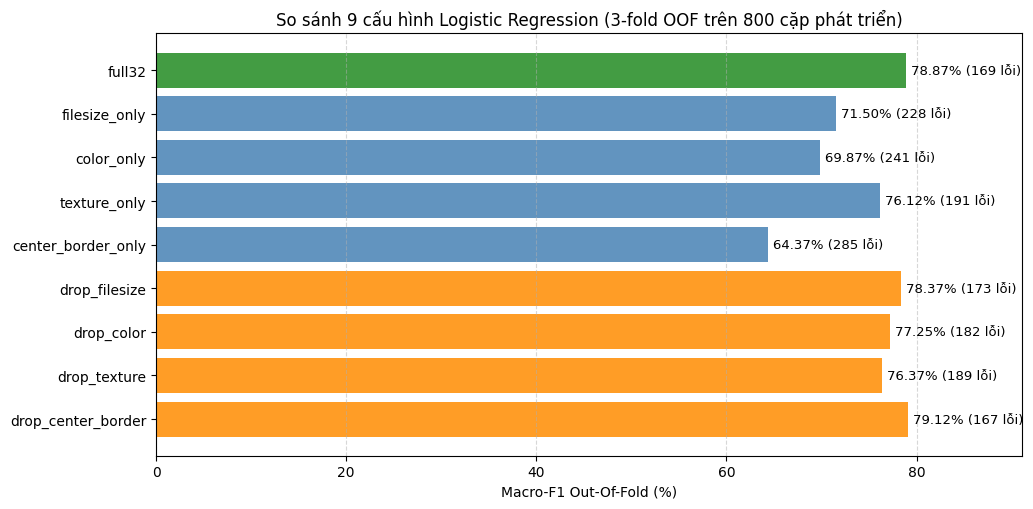

In [7]:
plt.figure(figsize=(10.5, 5.2))
bar_colors = ['forestgreen'] + ['steelblue'] * 4 + ['darkorange'] * 4
y_indices = np.arange(len(table_probes))
f1_vals = table_probes['macro_f1'].to_numpy() * 100

plt.barh(y_indices, f1_vals, color=bar_colors, alpha=0.85)
plt.yticks(y_indices, table_probes['variant'])
plt.xlabel("Macro-F1 Out-Of-Fold (%)")
plt.title("So sánh 9 cấu hình Logistic Regression (3-fold OOF trên 800 cặp phát triển)")
plt.gca().invert_yaxis()

for idx, (f1_score, err_count) in enumerate(zip(f1_vals, table_probes['errors'])):
    plt.text(f1_score + 0.5, idx, f"{f1_score:.2f}% ({err_count} lỗi)", va='center', fontsize=9.5)

plt.xlim(0, max(f1_vals) + 12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Đọc hai kiểu ablation riêng nhau

Các thanh xanh lam là nhóm dùng riêng. So chúng với nhau để biết nhóm nào dự đoán tốt trong model này. Các thanh cam là phiên bản bỏ nhóm; mỗi thanh cần so với full32 màu xanh lục.

Nếu một nhóm dùng riêng tốt nhưng bỏ đi ít thay đổi kết quả, nó có thể cung cấp thông tin đã có ở nhóm khác. Nếu bỏ nhóm làm điểm giảm, kết quả ủng hộ giữ nhóm trong pipeline đang thử. Nếu bỏ nhóm làm điểm tăng, một model gọn hơn đáng được kiểm tra tiếp. Những cách giải thích này cần được đối chiếu qua fold hoặc lượt chạy khác trước khi coi là ổn định.

Đọc cả Macro-F1 và số lỗi. Chênh lệch nhỏ có thể đến từ vài cặp đổi dự đoán; cũng chưa đủ để kết luận đã tìm ra dấu vết sinh ảnh.

## 5. Xem model đúng và sai trên ảnh nào

Lấy một ca đúng và một ca sai đầu tiên theo `pair_id` trong OOF của full32. Cách chọn này giúp lặp lại ví dụ, không đảm bảo đại diện cho toàn bộ lỗi.

Đọc nhãn và xác suất trước, sau đó nhìn ảnh để đặt câu hỏi. Chẳng hạn, có vùng nhỏ nào các số tóm tắt toàn ảnh khó diễn tả không? Đó mới là giả thuyết để kiểm tra; chỉ thấy một cặp sai chưa xác định được lý do model sai.

Ca đoán đúng: Cặp 00005 (Fold 0), p(phải giả)=0.7838, Thực tế=1, Đoán=1


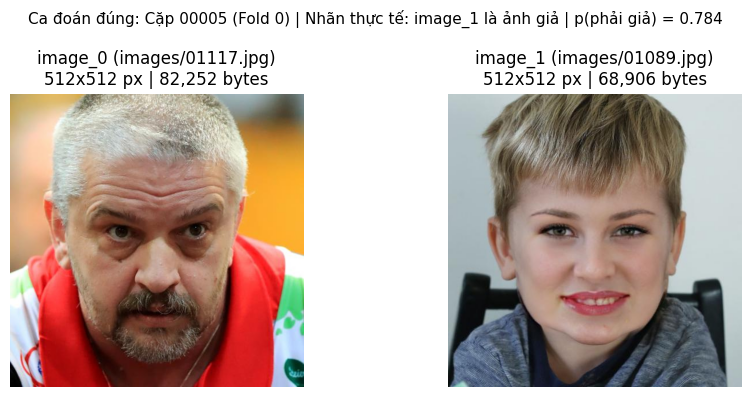

Ca đoán sai: Cặp 00001 (Fold 2), p(phải giả)=0.2472, Thực tế=1, Đoán=0


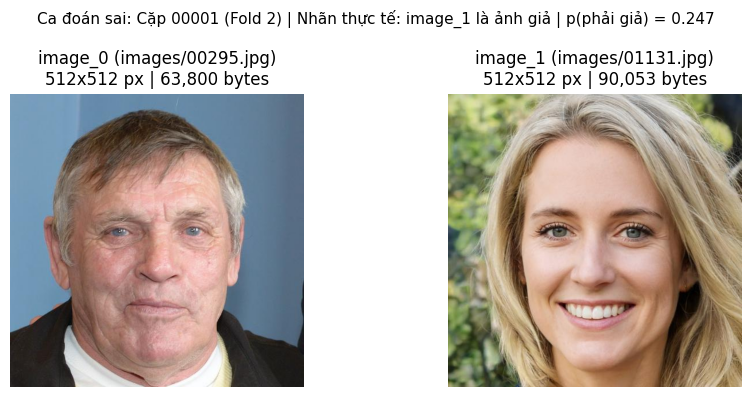

In [8]:
oof_df = preds_probes['lr_full32'].sort_values('pair_id').reset_index(drop=True)
oof_df['chosen'] = (oof_df['p'] >= 0.5).astype(int)
oof_df['is_correct'] = (oof_df['chosen'] == oof_df['fake_position']).astype(int)

correct_oof = oof_df.loc[oof_df.is_correct == 1].sort_values('pair_id')
error_oof = oof_df.loc[oof_df.is_correct == 0].sort_values('pair_id')

if not correct_oof.empty:
    sample_c = correct_oof.iloc[0]
    print(f"Ca đoán đúng: Cặp {sample_c.pair_id} (Fold {sample_c.inner_fold}), p(phải giả)={sample_c.p:.4f}, Thực tế={sample_c.fake_position}, Đoán={sample_c.chosen}")
    show_pair_images(sample_c, data_root, title=f"Ca đoán đúng: Cặp {sample_c.pair_id} (Fold {sample_c.inner_fold})", p_pred=sample_c.p)

if not error_oof.empty:
    sample_e = error_oof.iloc[0]
    print(f"Ca đoán sai: Cặp {sample_e.pair_id} (Fold {sample_e.inner_fold}), p(phải giả)={sample_e.p:.4f}, Thực tế={sample_e.fake_position}, Đoán={sample_e.chosen}")
    show_pair_images(sample_e, data_root, title=f"Ca đoán sai: Cặp {sample_e.pair_id} (Fold {sample_e.inner_fold})", p_pred=sample_e.p)

## 6. Từ kết quả LR đến phép thử tiếp theo

Ghi lại ba điều từ lượt chạy: LR so với luật dung lượng trên cùng OOF; nhóm đáng giữ theo các phép thêm/bớt; và một lỗi cần tìm hiểu thêm. Không cần giả định trước rằng model đủ đặc trưng luôn thắng.

Các phép đo đã có gradient và thống kê vùng, nhưng vẫn nén mỗi ảnh thành 32 số cố định. Chúng không giữ toàn bộ cách chi tiết sắp xếp trong ảnh. Ví dụ, hai bố cục khác nhau có thể cùng mean và std; điều này giải thích một giới hạn của phép tóm tắt, chưa giải thích mọi lỗi LR.

Một hướng tiếp theo là thử bộ trích xuất học từ ảnh và xem nó có cải thiện trên cùng validation hay không. Bài tiếp theo sẽ bắt đầu bằng cách xem đầu vào CNN, rồi so sánh giữ nguyên đặc trưng pretrained với điều chỉnh chúng cho dữ liệu của bài toán.

## Đọc thêm: vì sao đổi chỗ hai ảnh đổi hai xác suất?

Gọi $D$ là phép chia từng chiều cho scale đã học từ train. Vì không trừ trung bình, $D(-x)=-D(x)$. LR không có hệ số chặn cho $p(x)=\sigma(w^TD(x))$.

Từ $\sigma(-z)=1-\sigma(z)$ suy ra $p(-x)=1-p(x)$. Với chiều có phương sai bằng 0, scaler dùng scale 1; tính chất đổi dấu vẫn giữ. Phép kiểm tra trong bài chỉ xác nhận tính nhất quán này, không đo khả năng phân biệt ảnh giả.